In [1]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt

from physion.analysis import tools

sys.path.append('../scripts')
from distinct_rest_vs_active import compute_high_arousal_cond

import random
from matplotlib.ticker import MultipleLocator

In [2]:
def plot_behavior_in_episodes(data,
                              ax=None,
                              running_speed_threshold=0.1,
                              pupil_threshold=2.9, 
                              metric=None, 
                              mylabel=False):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(2,1.3))
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
    else:
        fig = None

    HAcount, LAcount = [], []
    for p, protocol in enumerate(protocols):
        try:
            
            behav_episodes = EpisodeData(data, 
                                         quantities=['dFoF', 'Pupil', 'Running-Speed'],
                                         protocol_name=protocol,
                                         prestim_duration=0,
                                         verbose=False)
        except:
            try: 
                behav_episodes = EpisodeData(data, 
                                 quantities=['dFoF', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
            except: 
                print("error when computing behavioral episodes")

        
        # HAcond: high arousal condition
        HAcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric=metric)

        ax.scatter(behav_episodes.pupil_diameter.mean(axis=1)[~HAcond],
                   behav_episodes.running_speed.mean(axis=1)[~HAcond],
                   color='grey',
                   s=2)
        ax.scatter(behav_episodes.pupil_diameter.mean(axis=1)[HAcond],
                   behav_episodes.running_speed.mean(axis=1)[HAcond],
                   color='orangered',
                   s=2)
        
        HAcount.append(np.sum(HAcond))
        LAcount.append(np.sum(~HAcond))
        
    ax.set_ylabel('run. speed (cm/s)', fontsize=9)
    ax.set_xlabel('pupil size (mm)', fontsize=9)
    ax.annotate('\n n=%i ep.' % np.sum(HAcount), (0, 1), color='orangered', xycoords='axes fraction', va='top', fontsize=7)
    ax.annotate(' n=%i ep.' % np.sum(LAcount), (0, 1), color='grey', xycoords='axes fraction', va='top', fontsize=7)
    ax.tick_params(axis='both', labelsize=7, pad=1, direction='out', length=4, width=1)
    ax.grid(False)
    ax.tick_params(axis='both', which='both', bottom=True, left=True)
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.set_title('Behavior across \n visual stimulation episodes', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    if metric=="locomotion":
        ax.axhline(running_speed_threshold, color = 'black', label = 'threshold', linewidth=0.6)
    elif metric=="pupil":
        ax.axvline(pupil_threshold, color = 'black', label = 'threshold', linewidth=0.6)  
    if mylabel:
        ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top', fontsize=7)
        ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top', fontsize=7)
    
    
    return fig, ax

In [3]:
def plot_average_visually_evoked_activity_NDNF(data,
                                           roiIndex=None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1, 
                                           metric=None):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    # prepare array for final results (averaged over sessions)
    RESULTS = {}
    for protocol in protocols:
        RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


    fig, AX = plt.subplots(5, len(protocols),
                              figsize=(7,5))
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HMcond: high movement condition
        HMcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric=metric)
        
        episodes = EpisodeData(data,
                               quantities=['dFoF'],
                               protocol_name=protocol,
                               verbose=False)
        varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
        varied_values = [episodes.varied_parameters[k] for k in varied_keys]

        AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                          (0.5,1.4),
                          xycoords='axes fraction', ha='center', fontsize=7)

        i=0
        for values in itertools.product(*varied_values):

            stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)

            #inset
            inset = pt.inset(AX[i][p], [0.55, 0.9, 0.3, 0.2])
            rest = sum(stim_cond & (~HMcond))
            run  = sum(stim_cond & HMcond)
            inset.pie([rest, run], 
                       autopct='%1.1f%%', 
                       colors = ['grey', 'orangered'], 
                       textprops={'fontsize': 5}, 
                       #labeldistance=0.5)  # Move labels outside
                       pctdistance=2  )  # Move percentage text closer to the edge

            #rest trace
            if np.sum(~HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & (~HMcond),
                                   with_std=False, with_stim=False,
                                   color='grey',
                                   AX=[[AX[i][p]]], no_set=True)
            #running trace
            if np.sum(HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & HMcond,
                                   with_std=False, with_stim=True,
                                   color='orangered',
                                   AX=[[AX[i][p]]], no_set=True)

            RESULTS[protocol]['significant'].append([])
            RESULTS[protocol]['response'].append([])
            RESULTS[protocol]['session'].append([])
            i+=1

    if roiIndex is None:
        AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[-1][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 0), xycoords='axes fraction', fontsize=7)

    pt.set_common_ylims(AX)
    for ax in pt.flatten(AX):
        ax.axis('off')
        if np.isfinite(ax.dataLim.x0) and ax==AX[0][0]:
            pt.draw_bar_scales(ax,
                               Xbar=1., Xbar_label='1s',
                               Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
    pt.set_common_xlims(AX)
    
    return fig

<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\D'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\D'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3415597169.py:80: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3415597169.py:94: SyntaxWarning: invalid escape sequence '\D'
  Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)


In [4]:
def plot_average_visually_evoked_activity(data,
                                           roiIndex=None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1,
                                           metric=None, 
                                           with_axis=False):
    
    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(2, 1, figsize=(4, 2), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')
    try :    
        episodes = EpisodeData(data,
                               quantities=['dFoF', 'Pupil', 'Running-Speed'],
                               protocol_name=protocol,
                               prestim_duration=1,
                               verbose=False)
    except: 
        try: 
            episodes = EpisodeData(data,
                               quantities=['dFoF', 'Running-Speed'],
                               protocol_name=protocol,
                               prestim_duration=1,
                               verbose=False)
        except: 
            try: 
                episodes = EpisodeData(data,
                               quantities=['dFoF', 'Pupil'],
                               protocol_name=protocol,
                               prestim_duration=1,
                               verbose=False)
            except : 
                print("behavioral data missing")

    
    
    HMcond = compute_high_arousal_cond(episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
    #HMcond = compute_high_movement_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric="locomotion")

    
    init_val = episodes.data.dFoF.mean(axis=0)[10631]
    max_val = np.max(episodes.data.dFoF.mean(axis=0))
    vdFoF = max_val - init_val
    
    
    #rest trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(~HMcond),
                       with_std=False, with_stim=False,
                       color='grey',
                       AX=[[AX[0][0]]], 
                       no_set=True, 
                       with_axis=with_axis)
       
    #running trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(HMcond),
                       with_std=False, with_stim=True,
                       color='orangered',
                       AX=[[AX[0][0]]], 
                       no_set=True, 
                       with_axis=with_axis)

    AX[0][0].set_xlabel("Time (0.5 ms)? check")
    AX[0][0].set_ylabel("dFoF ")
    
    #inset
    inset = pt.inset(AX[0][0], [0.55, 0.9, 0.3, 0.2])
    rest = sum(~HMcond)
    run  = sum(HMcond)
    inset.pie([rest, run], 
               autopct='%1.1f%%', 
               colors = ['grey', 'orangered'], 
               textprops={'fontsize': 5}, 
               pctdistance=2  )  # Move percentage text closer to the edge
    
    RESULTS['significant'].append([])
    RESULTS['response'].append([])
    RESULTS['session'].append([])
        

    if roiIndex is None:
        AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[0][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 1.2), xycoords='axes fraction')


    #plot traces running speed
    
    AX[1][0].plot(np.arange(0,len(episodes.running_speed[0]),1), episodes.running_speed[~HMcond][roiIndex], color= 'grey')
    AX[1][0].plot(np.arange(0,len(episodes.running_speed[0]),1), episodes.running_speed[HMcond][roiIndex], color= 'orangered')
    AX[1][0].set_xlabel("Time (0.5 ms)? check")
    AX[1][0].set_ylabel("Speed (cm/s)")

    
    return fig

<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:90: SyntaxWarning: invalid escape sequence '\p'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1037896573.py:90: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


In [5]:
def plot_average_visually_evoked_activity_(data,
                                           roiIndex=None,
                                           spe_episode = None,
                                           pupil_threshold=2.9,
                                           running_speed_threshold=0.1,
                                           metric=None, 
                                           with_axis=False):
    
    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(2, 1, figsize=(4, 2), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')

    if spe_episode is not None: 
        print("only 1 episode")

    else: 
        try :    
            episodes = EpisodeData(data,
                                   quantities=['dFoF', 'Pupil', 'Running-Speed'],
                                   protocol_name=protocol,
                                   prestim_duration=1,
                                   verbose=False)
        except: 
            try: 
                episodes = EpisodeData(data,
                                   quantities=['dFoF', 'Running-Speed'],
                                   protocol_name=protocol,
                                   prestim_duration=1,
                                   verbose=False)
            except: 
                try: 
                    episodes = EpisodeData(data,
                                   quantities=['dFoF', 'Pupil'],
                                   protocol_name=protocol,
                                   prestim_duration=1,
                                   verbose=False)
                except : 
                    print("behavioral data missing")
    
        
        
        HMcond = compute_high_arousal_cond(episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
        #HMcond = compute_high_movement_cond(behav_episodes, pupil_threshold, running_speed_threshold, metric="locomotion")
    
        
        init_val = episodes.data.dFoF.mean(axis=0)[10631]
        max_val = np.max(episodes.data.dFoF.mean(axis=0))
        vdFoF = max_val - init_val
        
        
        #rest trace
        plot_trial_average(episodes, 
                           roiIndex=roiIndex,
                           condition=(~HMcond),
                           with_std=False, with_stim=False,
                           color='grey',
                           AX=[[AX[0][0]]], 
                           no_set=True, 
                           with_axis=with_axis)
           
        #running trace
        plot_trial_average(episodes, 
                           roiIndex=roiIndex,
                           condition=(HMcond),
                           with_std=False, with_stim=True,
                           color='orangered',
                           AX=[[AX[0][0]]], 
                           no_set=True, 
                           with_axis=with_axis)
    
        AX[0][0].set_xlabel("Time (0.5 ms)? check")
        AX[0][0].set_ylabel("dFoF ")
        
        #inset
        inset = pt.inset(AX[0][0], [0.55, 0.9, 0.3, 0.2])
        rest = sum(~HMcond)
        run  = sum(HMcond)
        inset.pie([rest, run], 
                   autopct='%1.1f%%', 
                   colors = ['grey', 'orangered'], 
                   textprops={'fontsize': 5}, 
                   pctdistance=2  )  # Move percentage text closer to the edge
        
        RESULTS['significant'].append([])
        RESULTS['response'].append([])
        RESULTS['session'].append([])
            
    
        if roiIndex is None:
            AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                            data.filename.replace('.nwb',''),data.nROIs),
                               (0, 0),
                              xycoords='axes fraction')
        else:
            AX[0][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                               (0, 1.2), xycoords='axes fraction')
    
    
        #plot traces running speed
        
        AX[1][0].plot(episodes.t, episodes.running_speed[~HMcond][roiIndex], color= 'grey')
        AX[1][0].plot(episodes.t, episodes.running_speed[HMcond][roiIndex], color= 'orangered')
        AX[1][0].set_xlabel("Time (s)")
        AX[1][0].set_ylabel("Speed (cm/s)")

    
    return fig

<>:96: SyntaxWarning: invalid escape sequence '\p'
<>:96: SyntaxWarning: invalid escape sequence '\p'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\340325864.py:96: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


In [6]:
def plot_locomotion(episodes, 
                    HMcond, 
                    episode_n = None, 
                    general=True, 
                    active=True, 
                    resting=True):

    fig, AX = plt.subplots(1, 1, figsize=(4, 2)) 
    fig.subplots_adjust(hspace=0.8)
    
    start = int(1000)
    end = int(start + episodes.time_duration[0]*1000)
    #start_ = 0
    #end_ = int(episodes.time_duration[0]*1000)
    start_sec = 0
    end_sec = int(episodes.time_duration[0])
    print("start :", start)
    print("end: ", end)
    
    if episode_n is None: #average of all episodes 
        print(f"average of {episodes.dFoF.shape[0]} episodes ({np.sum(HMcond)} active, {len(HMcond)-np.sum(HMcond)} resting)")
         
        if general:
            AX.plot(episodes.t, episodes.running_speed[:, :].mean(axis=0), color='blue')
            value = episodes.running_speed[:, start:end].mean(axis=0).mean(axis=0)
            AX.hlines(value,
                      xmin = start_sec,
                      xmax = end_sec,
                      color='dimgray',
                      linestyle=':')
            print("value to compare to threshold : ", value)
        
        if active: 
            AX.plot(episodes.t, episodes.running_speed[HMcond, :].mean(axis=0), color="orangered")
            value = episodes.running_speed[HMcond, start:end].mean(axis=0).mean(axis=0)
            AX.hlines(value,
                      xmin = start_sec,
                      xmax = end_sec,
                      color='dimgray',
                      linestyle=':')
            print("value to compare to threshold : ", value)
            
        if resting: 
            AX.plot(episodes.t, episodes.running_speed[~HMcond, :].mean(axis=0), color = "grey")
            value = episodes.running_speed[~HMcond, start:end].mean(axis=0).mean(axis=0)
            AX.hlines(value,
                      xmin = start_sec,
                      xmax = end_sec,
                      color='dimgray',
                      linestyle=':')
            print("value to compare to threshold : ", value)
                
    else: #specific episode
        state = ['active' if HMcond[episode_n] else 'resting']
        color = 'orangered' if HMcond[episode_n] else 'grey'
        #color = 'blue' 
        print(f"Specific episode # {episode_n} ({state})") 
        #AX.plot(episodes.t, episodes.running_speed[episode_n, 0:end], color=color)  
        AX.plot(episodes.t, episodes.running_speed[episode_n, :],color=color)
        AX.hlines(episodes.running_speed[episode_n, start:end].mean(axis=0),
                  xmin = start_sec,
                  xmax = end_sec,
                  color='dimgray',
                  linestyle=':')
        print("value to compare to threshold : ", episodes.running_speed[episode_n,start:end].mean(axis=0))
            
    AX.set_ylabel('locomotion (cm/s)', fontsize=9)
    AX.axvspan(0, episodes.time_duration[0], color='lightgrey')
    AX.set_xlabel('Time (s)', fontsize=9)
    AX.annotate('Visual stimulation', (0.30, 1), color='black', xycoords='axes fraction', va='top', fontsize=7)
    AX.tick_params(axis='both', labelsize=7, pad=1, direction='out', length=4, width=1)
    AX.grid(False)
    AX.tick_params(axis='both', which='both', bottom=True, left=True)
    AX.axhline(0.1, color="crimson")
    #AX.set_xlim(-1, 4)
    
    return 0

In [46]:
def plot_dFoF_locomotion(episodes, 
                         HMcond, 
                         roi_n=None, 
                         episode_n = None, 
                         general=True, 
                         active=True, 
                         resting=True):

    fig, AX = plt.subplots(2, 1, figsize=(4, 2)) 
    fig.subplots_adjust(hspace=0.8)

    if episode_n is None: #average of all episodes 
     
        print(f"average of {episodes.dFoF.shape[0]} episodes ({np.sum(HMcond)} active, {len(HMcond)-np.sum(HMcond)} resting)")
        if roi_n is None:
            print(f"average of {episodes.dFoF.shape[1]} ROIs")
            if general:
                AX[0].plot(episodes.t, episodes.dFoF[:, :, :].mean(axis=0).mean(axis=0), color='blue') 
                AX[1].plot(episodes.t, episodes.running_speed[:, :].mean(axis=0), color='blue')
            if active: 
                AX[0].plot(episodes.t, episodes.dFoF[HMcond, :, :].mean(axis=0).mean(axis=0), color='orangered') 
                AX[1].plot(episodes.t, episodes.running_speed[HMcond, :].mean(axis=0), color="orangered")
            if resting: 
                AX[0].plot(episodes.t, episodes.dFoF[~HMcond, :, :].mean(axis=0).mean(axis=0), color = 'grey') 
                AX[1].plot(episodes.t, episodes.running_speed[~HMcond, :].mean(axis=0), color = "grey")
             
        else: 
            print(f"Specific ROI # {roi_n}")
            if general:
                AX[0].plot(episodes.t, episodes.dFoF[:, roi_n, :].mean(axis=0), color='blue') 
                AX[1].plot(episodes.t, episodes.running_speed[:, :].mean(axis=0), color='blue')
            if active: 
                AX[0].plot(episodes.t, episodes.dFoF[HMcond, roi_n, :].mean(axis=0), color='orangered') 
                AX[1].plot(episodes.t, episodes.running_speed[HMcond, :].mean(axis=0), color="orangered")
            if resting: 
                AX[0].plot(episodes.t, episodes.dFoF[~HMcond, roi_n, :].mean(axis=0), color = 'grey') 
                AX[1].plot(episodes.t, episodes.running_speed[~HMcond, :].mean(axis=0), color = "grey")
                
    else: #specific episode
        state = ['active' if HMcond[episode_n] else 'resting']
        #color = 'orangered' if HMcond[episode_n] else 'grey'
        color = 'blue' 
        print(f"Specific episode # {episode_n} ({state})")
        
        if roi_n is None: 
            print(f"average of {episodes.dFoF.shape[1]} ROIs")
            AX[0].plot(episodes.t, episodes.dFoF[episode_n, :, :].mean(axis=0), color=color) 
            AX[1].plot(episodes.t, episodes.running_speed[episode_n, :], color=color)
        else: 
            print(f"Specific ROI # {roi_n}")
            AX[0].plot(episodes.t, episodes.dFoF[episode_n, roi_n, :], color=color) 
            AX[1].plot(episodes.t, episodes.running_speed[episode_n, :], color=color)
            
    AX[0].set_ylabel('dFoF', fontsize=9)
    AX[1].set_ylabel('locomotion (cm/s)', fontsize=9)

    for ax in AX:
        ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.annotate('Visual stimulation', (0.30, 1), color='black', xycoords='axes fraction', va='top', fontsize=7)
        ax.tick_params(axis='both', labelsize=7, pad=1, direction='out', length=4, width=1)
        ax.grid(False)
        ax.tick_params(axis='both', which='both', bottom=True, left=True)

    return 0

In [55]:
def plot_dFoF_locomotion_all(all_episodes, 
                         all_HMcond, 
                         general=True, 
                         active=True, 
                         resting=True):

    fig, AX = plt.subplots(2, 1, figsize=(4, 2)) 
    fig.subplots_adjust(hspace=0.9)

    num_epi_all = 0
    num_roi_all = 0
    for i in range(len(all_episodes)):
        temp_epi = all_episodes[i].dFoF.shape[0]
        num_epi_all += temp_epi
        temp_roi = all_episodes[i].dFoF.shape[1]
        num_roi_all += temp_roi
    print(f"{len(all_episodes)} files")
    print(f"average of {num_epi_all} episodes ({np.sum(np.concatenate(all_HMcond))} active, {len(np.concatenate(all_HMcond))-np.sum(np.concatenate(all_HMcond))} resting)")
    print(f"average of {num_roi_all} ROIs")

    mean_dFoF = np.mean([ep.dFoF.mean(axis=(0, 1)) for ep in all_ep], axis=0)
    mean_running_speed = np.mean([ep.running_speed.mean(axis=0) for ep in all_ep], axis=0)
    
    mean_dFoF_active = np.mean([ep.dFoF[cond, :, :].mean(axis=(0, 1)) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
    mean_running_active = np.mean([ep.running_speed[cond, :].mean(axis=0) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
    
    mean_dFoF_rest = np.mean([ep.dFoF[~cond, :, :].mean(axis=(0, 1)) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
    mean_running_rest = np.mean([ep.running_speed[~cond, :].mean(axis=0) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
  
    if general:
        AX[0].plot(all_ep[0].t, mean_dFoF, color='blue') 
        AX[1].plot(all_ep[0].t, mean_running_speed, color='blue')
    if active: 
        AX[0].plot(all_ep[0].t, mean_dFoF_active, color='orangered') 
        AX[1].plot(all_ep[0].t, mean_running_active, color="orangered")
    if resting: 
        AX[0].plot(all_ep[0].t, mean_dFoF_rest, color = 'grey') 
        AX[1].plot(all_ep[0].t, mean_running_rest, color = "grey")
             
    
    AX[0].set_ylabel('dFoF', fontsize=9)
    AX[1].set_ylabel('locomotion (cm/s)', fontsize=9)

    for ax in AX:
        ax.axvspan(0, int(np.unique(all_episodes[0].time_duration)), color='lightgrey')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.annotate('Visual stimulation', (0.30, 1), color='black', xycoords='axes fraction', va='top', fontsize=7)
        ax.tick_params(axis='both', labelsize=7, pad=1, direction='out', length=4, width=1)
        ax.grid(False)
        ax.tick_params(axis='both', which='both', bottom=True, left=True)
    
    return 0

# NDNF 2022

In [67]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 12.8s) 


## Example with 1 file (check index below)

In [68]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

In [71]:
data.protocols

array(['moving-dots', 'random-dots', 'static-patch', 'looming-stim',
       'Natural-Images-4-repeats', 'grey-10min', 'drifting-gratings'],
      dtype='<U24')

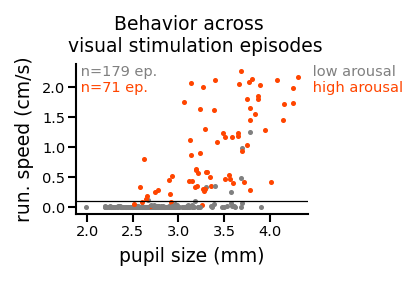

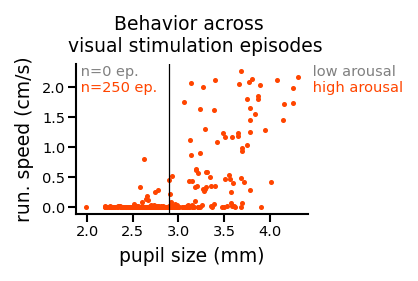

In [70]:
running_speed_threshold=0.1
pupil_threshold = 2.9
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=running_speed_threshold, pupil_threshold=pupil_threshold, metric="locomotion", mylabel=True)
fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/behavior_locomotion_pupil1.png", dpi=300, bbox_inches='tight')

fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=running_speed_threshold, pupil_threshold=pupil_threshold, metric="pupil", mylabel=True)
fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/behavior_locomotion_pupil2.png", dpi=300, bbox_inches='tight')

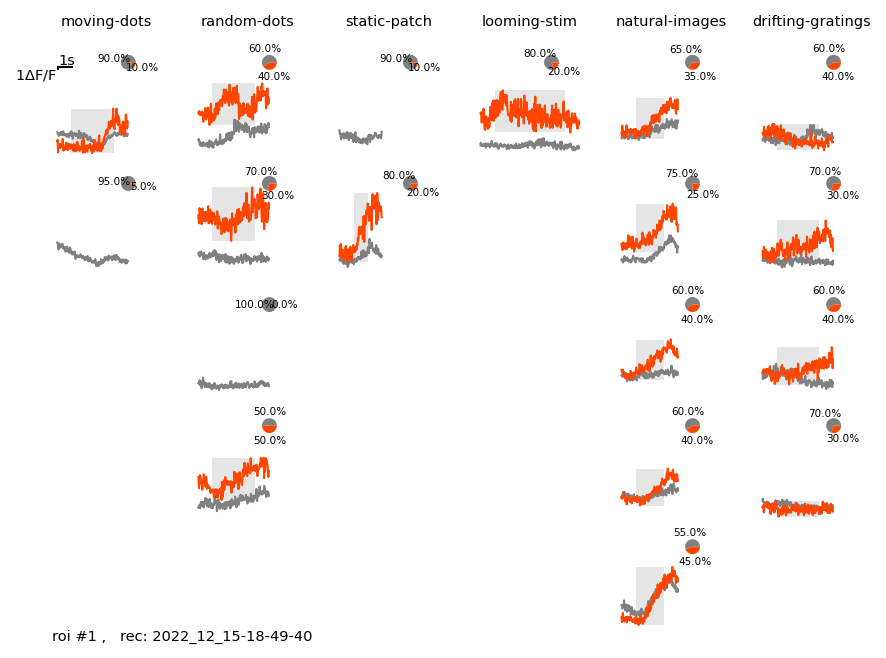

In [13]:
dataIndex, roiIndex = 2, 0
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
fig = plot_average_visually_evoked_activity_NDNF(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')
fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/behavior_different_stim.png", dpi=300, bbox_inches='tight')

### plot locomotion only

  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
start : 1000
end:  2000
Specific episode # 18 (['resting'])
value to compare to threshold :  0.0


0

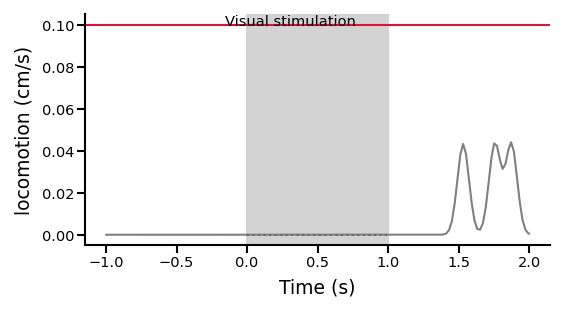

In [14]:
#Load episodes by protocol!
protocol = "static-patch"
pre_stim = 1
Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol, 
                 prestim_duration=pre_stim)

HMcond = compute_high_arousal_cond(Ep, 
                                   pre_stim = pre_stim,
                                   pupil_threshold = 0.29, 
                                   running_speed_threshold = 0.1, 
                                   metric = 'locomotion')

epi_num = random.randint(0, Ep.dFoF.shape[0]-1) #chosen randomly  #34 is active   #2 is weird #22

plot_locomotion(Ep, 
                HMcond,  
                episode_n = epi_num, 
                general=True, 
                active=False, 
                resting=False)

In [75]:
protocol = "moving-dots"
pre_stim = 1
Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol, 
                 prestim_duration=pre_stim)

HMcond = compute_high_arousal_cond(Ep, 
                                   pre_stim = pre_stim,
                                   pupil_threshold = 0.29, 
                                   running_speed_threshold = 0.1, 
                                   metric = 'locomotion')

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !


### Specific ROI, specific episode

In [18]:
protocol = 'moving-dots'

Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol)
HMcond = compute_high_arousal_cond(Ep, 
                                   pre_stim = 1,
                                   pupil_threshold = 0.29, 
                                   running_speed_threshold = 0.1, 
                                   metric = 'locomotion')

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !


Specific episode # 15 (['resting'])
Specific ROI # 43


0

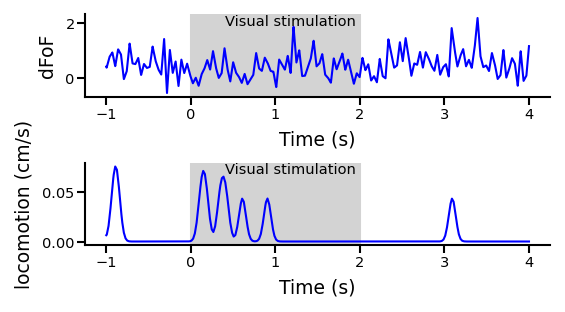

In [19]:
roi = random.randint(0, Ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, Ep.dFoF.shape[0]-1) #chosen randomly  #34 is active

plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=False, 
                     resting=False)

### Specific episode, average ROI

Specific episode # 18 (['resting'])
average of 66 ROIs


0

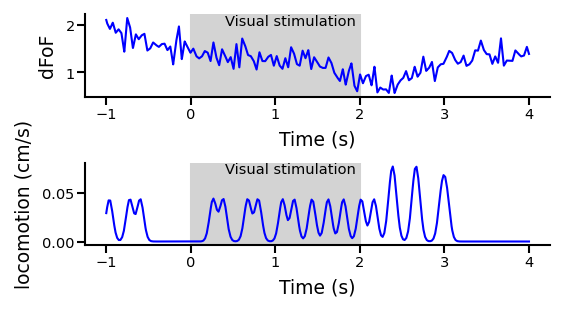

In [21]:
epi_num = random.randint(0, Ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

### Specific ROI, average episodes

average of 40 episodes (6 active, 34 resting)
Specific ROI # 17
aa  3
aa  3


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("aa ", int(np.unique(episodes.time_duration)))
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')


0

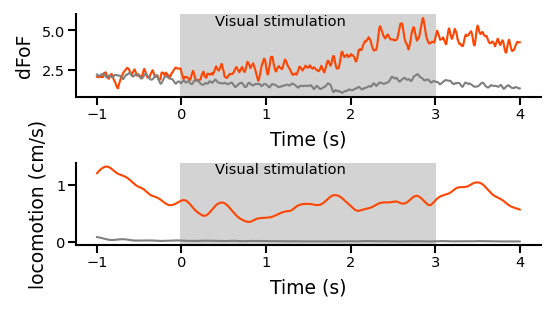

In [86]:
roi = 17 #random.randint(0, Ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

average of 40 episodes (9 active, 9 resting)
Specific ROI # 61


IndexError: boolean index did not match indexed array along axis 0; size of axis is 40 but size of corresponding boolean axis is 18

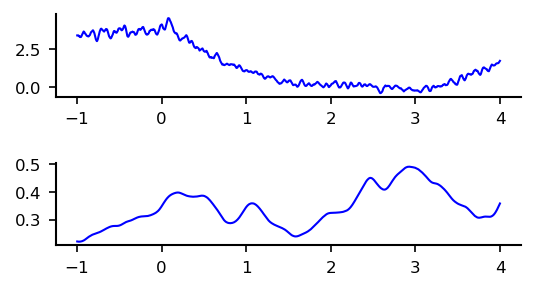

In [63]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

average of 40 episodes (9 active, 9 resting)
Specific ROI # 14


IndexError: boolean index did not match indexed array along axis 0; size of axis is 40 but size of corresponding boolean axis is 18

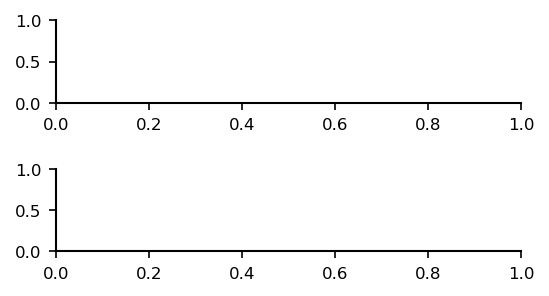

In [64]:
roi = 14 #random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Average ROI, average episodes

In [ ]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

## All files

In [ ]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='locomotion', mylabel=False)
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    
for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/all_behavior_locomotion_pupil1.png", dpi=300, bbox_inches='tight')

In [ ]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='pupil', mylabel=False)
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    
for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/all_behavior_locomotion_pupil2.png", dpi=300, bbox_inches='tight')

### ALL files, average ROI, average episodes

In [ ]:
all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     protocol_id=0,
                     quantities=['dFoF', 'running_speed', 'pupil'])
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

In [ ]:
print(df)

In [ ]:
dataset = "NDNF"
protocol = "moving-dots"
print("dataset : ", dataset)
print("protocol : ", protocol)

plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

### test other protocols

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
Protocol :  moving-dots
average of 40 episodes (7 active, 33 resting)
average of 66 ROIs
aa  3
aa  3


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("aa ", int(np.unique(episodes.time_duration)))
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')


0

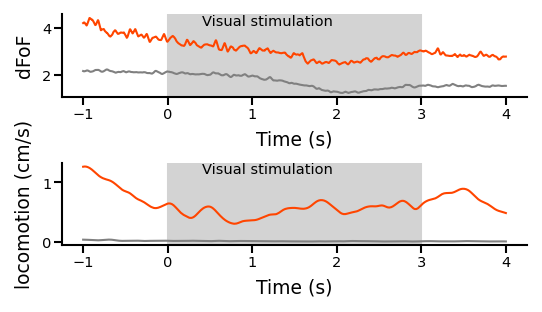

In [47]:
protocol = 'moving-dots'

Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### random dots

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
Protocol :  random-dots
average of 40 episodes (11 active, 29 resting)
average of 66 ROIs
aa  3
aa  3


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("aa ", int(np.unique(episodes.time_duration)))
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')


0

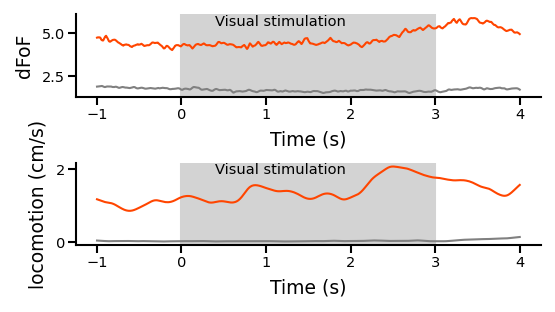

In [48]:
protocol = 'random-dots'

Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### static patch

  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
Protocol :  static-patch
average of 20 episodes (3 active, 17 resting)
average of 66 ROIs
aa  1
aa  1


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("aa ", int(np.unique(episodes.time_duration)))
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')


0

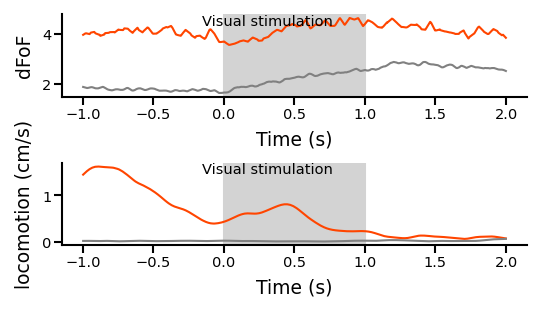

In [49]:
protocol = 'static-patch'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### looming stim

  Number of episodes over the whole recording: 10/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
Protocol :  looming-stim
average of 10 episodes (2 active, 8 resting)
average of 66 ROIs
aa  5
aa  5


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("aa ", int(np.unique(episodes.time_duration)))
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')


0

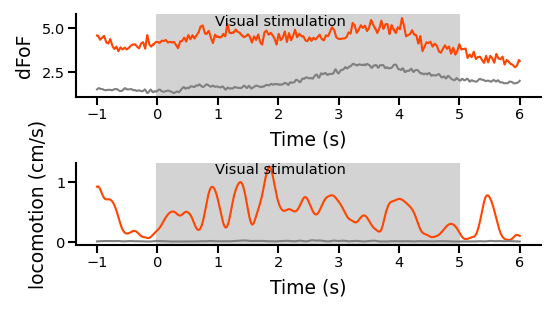

In [50]:
protocol = 'looming-stim'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Natural images 4 repeats

  Number of episodes over the whole recording: 100/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
Protocol :  Natural-Images-4-repeats
average of 100 episodes (35 active, 65 resting)
average of 66 ROIs
aa  2
aa  2


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("aa ", int(np.unique(episodes.time_duration)))
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')


0

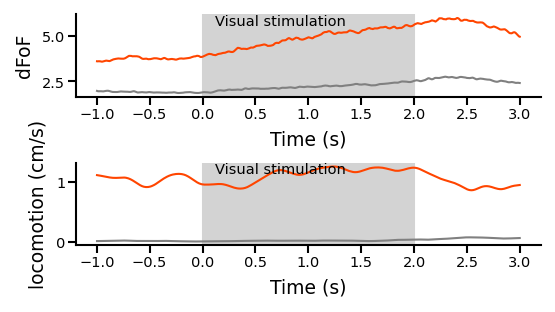

In [51]:
protocol = 'Natural-Images-4-repeats'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### drifting gratings

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
Protocol :  drifting-gratings
average of 40 episodes (10 active, 30 resting)
average of 66 ROIs
aa  3
aa  3


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("aa ", int(np.unique(episodes.time_duration)))
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\1336814746.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(episodes.time_duration)), color='lightgrey')


0

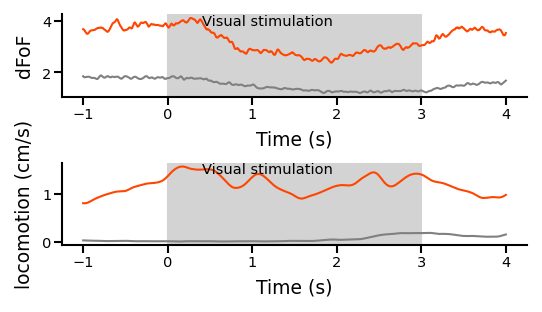

In [52]:
protocol = 'drifting-gratings'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### for all files

In [53]:
dataset = "NDNF"

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 39/241 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building epi

C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3517385488.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(all_episodes[0].time_duration)), color='lightgrey')


0

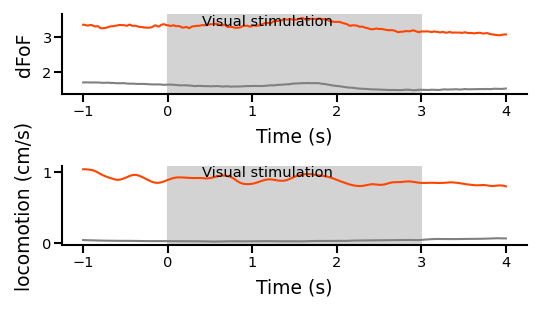

In [56]:
protocol = "moving-dots"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 39/241 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building epi

C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3517385488.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(all_episodes[0].time_duration)), color='lightgrey')


0

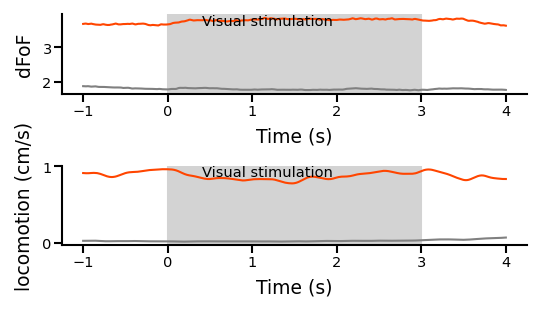

In [57]:
protocol = "random-dots"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 18/241 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 20/251 (with protocol condition)
  building epi

C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3517385488.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(all_episodes[0].time_duration)), color='lightgrey')


0

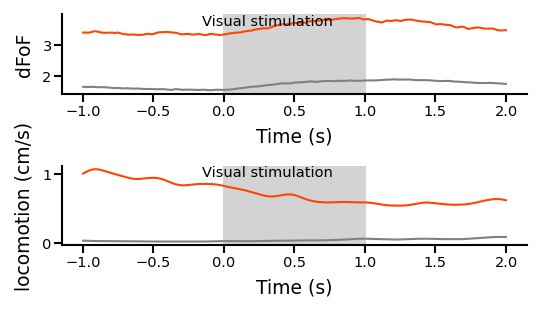

In [58]:
protocol = "static-patch"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

  Number of episodes over the whole recording: 10/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 10/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 10/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 10/241 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 10/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 10/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 10/251 (with protocol condition)
  building epi

C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3517385488.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(all_episodes[0].time_duration)), color='lightgrey')


0

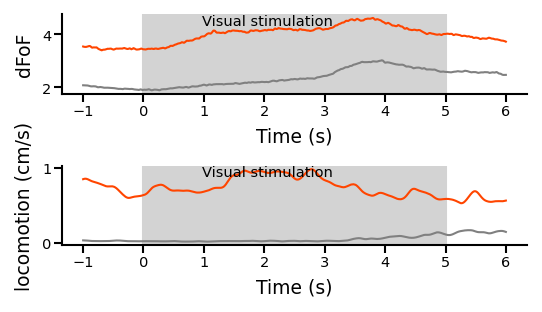

In [59]:
protocol = "looming-stim"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

  Number of episodes over the whole recording: 100/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 100/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 100/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 97/241 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 100/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 100/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 100/251 (with protocol condition)
  buildi

C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3517385488.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(all_episodes[0].time_duration)), color='lightgrey')


0

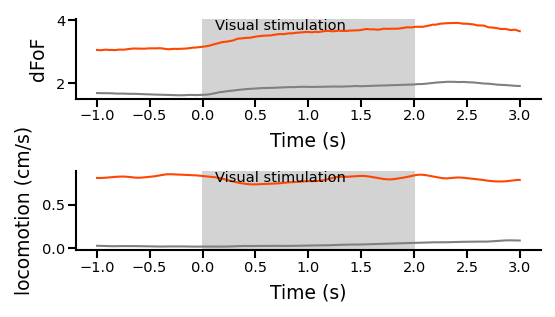

In [60]:
protocol = 'Natural-Images-4-repeats'

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 37/241 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building epi

C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_17140\3517385488.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvspan(0, int(np.unique(all_episodes[0].time_duration)), color='lightgrey')


0

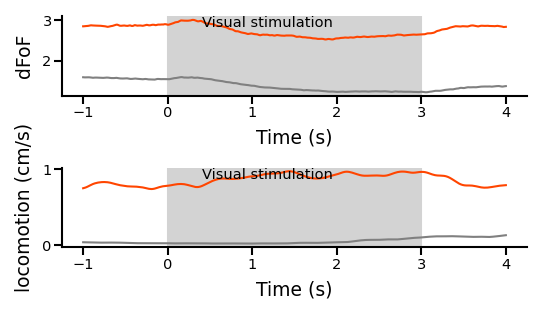

In [61]:
protocol = 'drifting-gratings'

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

---------------------

# SST Keta vs Saline Cibele and Sofia 2024-2025

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

In [ ]:
dataIndex = 4
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
data.build_running_speed()
#print(data.pupil_diameter.shape)
print(data.running_speed.shape)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1, metric='locomotion')
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

In [ ]:
rows = 4
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], running_speed_threshold=0.1, metric='locomotion')
    except Exception as e:
        print(f"Error{e}")
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)


for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

In [ ]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

### Specific ROI, specific episode

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

### Specific ROI, average episodes

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Average ROI, average episodes

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### ALL files, average ROI, average episodes

In [ ]:
all_ep = []
all_HMcond = []

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)

all_HMcond = np.concatenate(all_HMcond)

In [ ]:
print(f"{len(SESSIONS['files'])} files")

plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         roi_n=None, 
                         episode_n = None, 
                         general=True, 
                         active=True, 
                         resting=True)

---

# SST Keta vs Saline Taddy Yann 2023  --- not enough data!!!

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','SST-Ketamine-vs-Saline', 'All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

In [ ]:
dataIndex = 4
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
data.build_running_speed()
data.build_pupil_diameter()
print(data.dFoF.shape)
print(data.pupil_diameter.shape)
print(data.running_speed.shape)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, pupil_threshold = 2.9, running_speed_threshold=0.1, metric='locomotion')
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

In [ ]:
rows = 1
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,2))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[f], running_speed_threshold=0.1, metric='locomotion')
    except Exception as e:
        print(f"Error{e}")
    AX[f].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)

In [ ]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

## Useless

In [1067]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !


In [ ]:
from physion.analysis.dataframe import NWB_to_dataframe
df_ = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)


running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pupil_size_dFoF_sampled = data.build_pupil_diameter(specific_time_sampling=data.t_dFoF)

df = pd.DataFrame()
df['dFoF'] = data.dFoF.mean(axis=0)   #average of all ROIs
df['running_speed'] = running_dFoF_sampled
df['behav_state'] = df['running_speed'].apply(lambda speed: True if speed > 0.1 else False)
df['stim_cond'] = (~df_['VisStim_grey-10min'])

print(df)
print(df_)

plt.figure(figsize=(8, 2))

fig, ax = pt.plt.subplots(1, 1, figsize=(10,2))

for i in range(len(df) - 1):
    if df['stim_cond'].iloc[i] == False:
        ax.axvspan(i, i+1, color='lightgrey', alpha=0.5)

print(np.sum(df['stim_cond'] == False))
        
ax.scatter(x = df['dFoF'].index, 
           y = df['dFoF'],  
           color = ['grey' if state == False else 'orangered' for state in df['behav_state']],
           s=1)
ax.set_xlabel("time (unit?)")
ax.set_ylabel("dFoF")

import seaborn as sns
# Set plot style
sns.set(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(5, 2))
g = sns.catplot(data=df, 
                 kind = 'violin',
                 x='stim_cond', 
                 y='dFoF', 
                 hue='behav_state', 
                 palette=['grey', 'orangered'], 
                 linewidth=0.8, 
                 legend_out = True)

g.set_xticklabels(["No visual Stimulus", "Visual stimulus"])
new_title = 'Behavioral state'
g._legend.set_title(new_title)
new_labels = ['rest', 'active']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
    

ax = g.ax  # Get the matplotlib axis
grouped = df.groupby(["stim_cond", "behav_state"]).size().reset_index(name='count')
for i, (x, hue) in enumerate(zip(grouped["stim_cond"], grouped["behav_state"])):
    print(x, hue)
    n = grouped.loc[(grouped["stim_cond"] == x) & (grouped["behav_state"] == hue), "count"].values[0]
    ax.text(i/2-0.2, 0, f"n={n}", ha="center", va="bottom", fontsize=12, color="black")

plt.show()

In [ ]:
'''
protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol


STAT_TEST = {}f
for protocol in protocols:
    STAT_TEST[protocol] = dict(interval_pre=[-1,0],
                               interval_post=[1,2],
                               test='ttest',
                               positive=True)
    
STAT_TEST['looming-stim']['interval_post'] = [2, 3]
STAT_TEST['drifting-gratings']['interval_post'] = [1.5, 2.5]
STAT_TEST['moving-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['random-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['static-patch']['interval_post'] = [0.5, 1.5]
'''

In [ ]:
filename = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'NDNF-WT-Dec-2022','NWBs',  '2022_12_14-13-27-41.nwb')
data = Data(filename, verbose=False)

data.build_dFoF()
data.build_running_speed()

ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

print(ep.dFoF.shape) # (episodes, rois, time samples)
n_episodes = ep.dFoF.shape[0]
#roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly
roi=11
print(roi)

fig, ax = pt.figure(figsize=(2, 2.5))
temp = ep.dFoF[:,roi,:]
print(temp.shape)
ax.plot(ep.t, temp.mean(axis=0)) #mean of all the episodes
ax.axvspan(0, 2, color='lightgrey')
ax.set_ylabel('dFoF')
ax.set_xlabel('time (s)')
ax.annotate('Visual stim', (0.25, 1), color='black', xycoords='axes fraction', va='top')

print(np.mean(ep.running_speed, axis=1))
ep.state = [True if speed > 0.07 else False for speed in np.mean(ep.running_speed, axis=1)]
print(ep.state)

fig, AX = pt.figure(axes=(2,1))
roi= random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly

for state, ax in zip(np.unique(ep.state), AX):
    pt.plot(ep.t, 
            ep.dFoF[ep.state==state, roi, :].mean(axis=0), 
            sy=ep.dFoF[ep.state==state, roi, :].std(axis=0), 
            ax=ax, title=state)

pt.set_common_ylims(AX)

print(len(ep.dFoF[ep.state==state, roi, :].mean(axis=0)))

i= 0
for run_speed in ep.running_speed :
    print(ep.state)
    if np.mean(run_speed, axis=0) > 0.5:
        ep.state[i] = True
    else: 
        ep.state[i] = False
    i+=1
roi=random.randint(0, ep.dFoF.shape[1]-1)

fig, ax1 = plt.subplots(figsize=(2, 2.5))
ax2 = ax1.twinx()
print(ep.running_speed.shape)
temp_dFoF = ep.dFoF[:,roi,:]
temp_running = ep.running_speed[roi,:]
print(temp_dFoF.shape)

ax1.plot(ep.t, temp_running)
ax2.plot(ep.t, temp_dFoF.mean(axis=0)) #mean of all the episodes
ax1.axvspan(0, 2, color='lightgrey')